In [114]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl.drawing.image import Image

### --> Specify the sofware version that is going to be used 
### --> Specify the runs collected for each run


In [115]:
bundle_version = '2.12.1.345'

ONLINE_RUNS_COLLECTED = 14  # Normalmente aqui el valor aqui es 15.  
                            # 5 runs x 3 samples = 15 


CURVE_RUNS_COLLECTED = 9        # 3 runs x 3 samples = 9 

In [116]:
# Se especifica aqui, Software version y el nombre del archivo excel que se exportara

filename_excel_report = bundle_version + '_Test Status Report.xlsx' 


#Se leen los archivos que tienen la informacion para el analisis 
df_OnlineAnalysis_csv = pd.read_csv('Results Metrics - EngagedAnalysis.csv')
df_EngagedAnalysis_csv = pd.read_csv('Results Metrics - EngagedAnalysis.csv')


#Specs for peaks and absolutes
spec_peaks = .05 # Spec for peaks - 5 cm  
spec_abs = .025 # Spec for abs - 2.5 cm   


In [117]:
#In case columns are not in CSV just raise an error

if 'MAXABSIMPXTE (m)' not in df_OnlineAnalysis_csv.columns and df_EngagedAnalysis_csv:
    raise KeyError(f"MAXABSIMPXTE (m) column is not in csv")

if 'AVGABSIMPXTE (m)' not in df_OnlineAnalysis_csv.columns and df_EngagedAnalysis_csv:
    raise KeyError(f"AVGABSIMPXTE (m) column is not in csv")

In [118]:
# Lista con el nombre de las columnas que nos seran utiles para el analisis. 

perf_metrics = ['Data Source','MAXABSIMPXTE (m)', 'AVGABSIMPXTE (m)'] 

# Se crea el dataframe que tendra las runs de straight swaths

df_online = df_OnlineAnalysis_csv[perf_metrics].iloc[0:ONLINE_RUNS_COLLECTED] 
df_online.index = range(1,ONLINE_RUNS_COLLECTED+1)

#Se crea el dataframe que tendra las runs de curve swaths.

df_curves = df_EngagedAnalysis_csv[perf_metrics].iloc[ONLINE_RUNS_COLLECTED:CURVE_RUNS_COLLECTED+ONLINE_RUNS_COLLECTED].copy()
df_curves.index = range(ONLINE_RUNS_COLLECTED+1,CURVE_RUNS_COLLECTED+ONLINE_RUNS_COLLECTED+1)


# Se crea el df que contendra los resultados de las corridas ONLINE y CURVES
# En este el dataframe "output_df_results" se encuentra en blanco de momento

columns_names = ["PEAKS AVG (m)", "ABS AVG (m)"] 
output_df_results =  pd.DataFrame(index= range(1,9), columns=columns_names) 

In [119]:
#Verifica que solo se vean las corridas desde run 1 hasta run 5. 
print(df_online["Data Source"].head(ONLINE_RUNS_COLLECTED+1))

1      Run 1 - Magnum_380_run_1_1.25mph_2
2      Run 2 - Magnum_380_run_1_1.25mph_3
3         Run 3 - Magnum_380_run_2_3mph_1
4         Run 4 - Magnum_380_run_2_3mph_2
5         Run 5 - Magnum_380_run_2_3mph_3
6       Run 6 - Magnum_380_run_3_6.2mph_1
7       Run 7 - Magnum_380_run_3_6.2mph_2
8       Run 8 - Magnum_380_run_3_6.2mph_3
9       Run 9 - Magnum_380_run_4_9.2mph_1
10     Run 10 - Magnum_380_run_4_9.2mph_2
11     Run 11 - Magnum_380_run_4_9.2mph_3
12    Run 12 - Magnum_380_run_5_12.4mph_1
13    Run 13 - Magnum_380_run_5_12.4mph_2
14    Run 14 - Magnum_380_run_5_12.4mph_3
Name: Data Source, dtype: str


In [120]:
#Verifica que solo se vean las corridas desde run 6 hasta run 8. 
print(df_curves["Data Source"].head(CURVE_RUNS_COLLECTED+1))

15    Run 15 - Magnum_380_run_6_5mph_1
16    Run 16 - Magnum_380_run_6_5mph_2
17    Run 17 - Magnum_380_run_6_5mph_3
18    Run 18 - Magnum_380_run_7_5mph_1
19    Run 19 - Magnum_380_run_7_5mph_2
20    Run 20 - Magnum_380_run_7_5mph_3
21    Run 21 - Magnum_380_run_8_8mph_1
22    Run 22 - Magnum_380_run_8_8mph_2
23    Run 23 - Magnum_380_run_8_8mph_3
Name: Data Source, dtype: str


#### Specify the ranges to analyze 

In [121]:
#Online runs start / stop index
run_1_start_index, run_1_stop_index = (1, 2)
run_2_start_index, run_2_stop_index = (3, 5)
run_3_start_index, run_3_stop_index = (6, 8)
run_4_start_index, run_4_stop_index = (9, 11)
run_5_start_index, run_5_stop_index = (12, 14)

In [122]:
#Curve runs start / stop index
run_6_start_index, run_6_stop_index = (15, 17)
run_7_start_index, run_7_stop_index = (18, 20)
run_8_start_index, run_8_stop_index = (21, 23)

In [123]:
#Aqui solo se crean SUB-DATAFRAMES 

#Online Dataframes
run_1_ranges = df_online.loc[run_1_start_index : run_1_stop_index]
run_2_ranges = df_online.loc[run_2_start_index : run_2_stop_index]
run_3_ranges = df_online.loc[run_3_start_index : run_3_stop_index]
run_4_ranges = df_online.loc[run_4_start_index : run_4_stop_index]
run_5_ranges = df_online.loc[run_5_start_index : run_5_stop_index]

#Curve Dataframes
run_6_ranges = df_curves.loc[run_6_start_index : run_6_stop_index]
run_7_ranges = df_curves.loc[run_7_start_index : run_7_stop_index]
run_8_ranges = df_curves.loc[run_8_start_index : run_8_stop_index]


In [124]:
#Verifica que los rangos sean correctos

print(f"\t\t\tRUN 1 SAMPLES - ONLINE\n")
print(run_1_ranges)
print(f"\n\t\t\tRUN 2 SAMPLES - ONLINE\n")
print(run_2_ranges)
print(f"\n\t\t\tRUN 3 SAMPLES - ONLINE\n")
print(run_3_ranges)
print(f"\n\t\t\tRUN 4 SAMPLES - ONLINE\n")
print(run_4_ranges)
print(f"\n\t\t\tRUN 5 SAMPLES -ONLINE\n")
print(run_5_ranges)


			RUN 1 SAMPLES - ONLINE

                          Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
1  Run 1 - Magnum_380_run_1_1.25mph_2             0.036             0.021
2  Run 2 - Magnum_380_run_1_1.25mph_3             0.036             0.017

			RUN 2 SAMPLES - ONLINE

                       Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
3  Run 3 - Magnum_380_run_2_3mph_1             0.049             0.019
4  Run 4 - Magnum_380_run_2_3mph_2             0.041             0.014
5  Run 5 - Magnum_380_run_2_3mph_3             0.051             0.014

			RUN 3 SAMPLES - ONLINE

                         Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
6  Run 6 - Magnum_380_run_3_6.2mph_1             0.128             0.034
7  Run 7 - Magnum_380_run_3_6.2mph_2             0.089             0.031
8  Run 8 - Magnum_380_run_3_6.2mph_3             0.064             0.025

			RUN 4 SAMPLES - ONLINE

                           Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
9    Run 9 - Mag

In [125]:
df_online

,Data Source,MAXABSIMPXTE (m),AVGABSIMPXTE (m)
1,Run 1 - Magnum_380_run_1_1.25mph_2,0.036,0.021
2,Run 2 - Magnum_380_run_1_1.25mph_3,0.036,0.017
3,Run 3 - Magnum_380_run_2_3mph_1,0.049,0.019
4,Run 4 - Magnum_380_run_2_3mph_2,0.041,0.014
5,Run 5 - Magnum_380_run_2_3mph_3,0.051,0.014
6,Run 6 - Magnum_380_run_3_6.2mph_1,0.128,0.034
7,Run 7 - Magnum_380_run_3_6.2mph_2,0.089,0.031
8,Run 8 - Magnum_380_run_3_6.2mph_3,0.064,0.025
9,Run 9 - Magnum_380_run_4_9.2mph_1,0.109,0.037
10,Run 10 - Magnum_380_run_4_9.2mph_2,0.098,0.031


<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

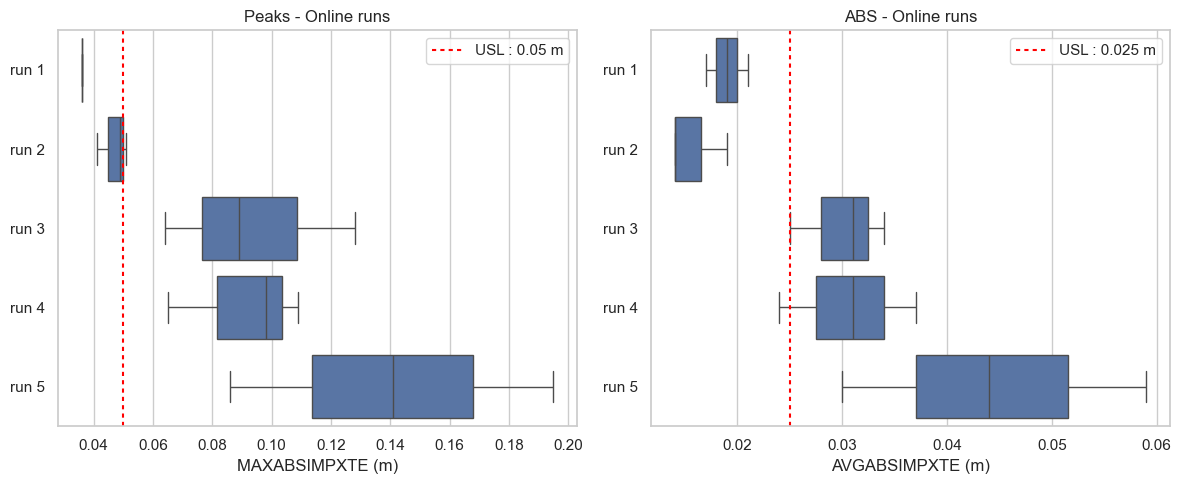

In [126]:
# Start by defining the figure. 
# row : 1, columns: 2

fig, axes = plt.subplots(1,2,figsize = (12,5))


# Definition of groups 

online_groups = ['run 1', 'run 1',
              'run 2', 'run 2', 'run 2',
              'run 3', 'run 3', 'run 3',
              'run 4', 'run 4', 'run 4',
              'run 5', 'run 5', 'run 5',
              ]


# Plot the first boxplot. Peaks on Online runs 

sns.boxplot(y = online_groups, 
            x = df_online["MAXABSIMPXTE (m)"],
            ax = axes[0])

axes[0].set_title("Peaks - Online runs")
axes[0].axvline(spec_peaks,color = 'red', dashes = (2,2), label = 'USL : 0.05 m')

axes[0].legend()

sns.boxplot(y = online_groups, 
            x = df_online["AVGABSIMPXTE (m)"],
            ax = axes[1])

axes[1].set_title("ABS - Online runs")
axes[1].axvline(spec_abs,color = 'red', dashes = (2,2), label = 'USL : 0.025 m')
axes[1].legend()


plt.tight_layout()
plt.savefig('Online_Plots.png', dpi=300)
plt.close


In [127]:
print(f"\n\t\t\tRUN 6 SAMPLES - CURVE\n")
print(run_6_ranges)

print(f"\n\t\t\tRUN 7 SAMPLES - CURVE \n")
print(run_7_ranges)

print(f"\n\t\t\tRUN 8 SAMPLES - CURVE \n")
print(run_8_ranges)


			RUN 6 SAMPLES - CURVE

                         Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
15  Run 15 - Magnum_380_run_6_5mph_1             0.081             0.021
16  Run 16 - Magnum_380_run_6_5mph_2             0.062             0.017
17  Run 17 - Magnum_380_run_6_5mph_3             0.051             0.015

			RUN 7 SAMPLES - CURVE 

                         Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
18  Run 18 - Magnum_380_run_7_5mph_1             0.097             0.030
19  Run 19 - Magnum_380_run_7_5mph_2             0.094             0.029
20  Run 20 - Magnum_380_run_7_5mph_3             0.092             0.027

			RUN 8 SAMPLES - CURVE 

                         Data Source  MAXABSIMPXTE (m)  AVGABSIMPXTE (m)
21  Run 21 - Magnum_380_run_8_8mph_1             0.158             0.049
22  Run 22 - Magnum_380_run_8_8mph_2             0.251             0.077
23  Run 23 - Magnum_380_run_8_8mph_3             0.142             0.066


<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

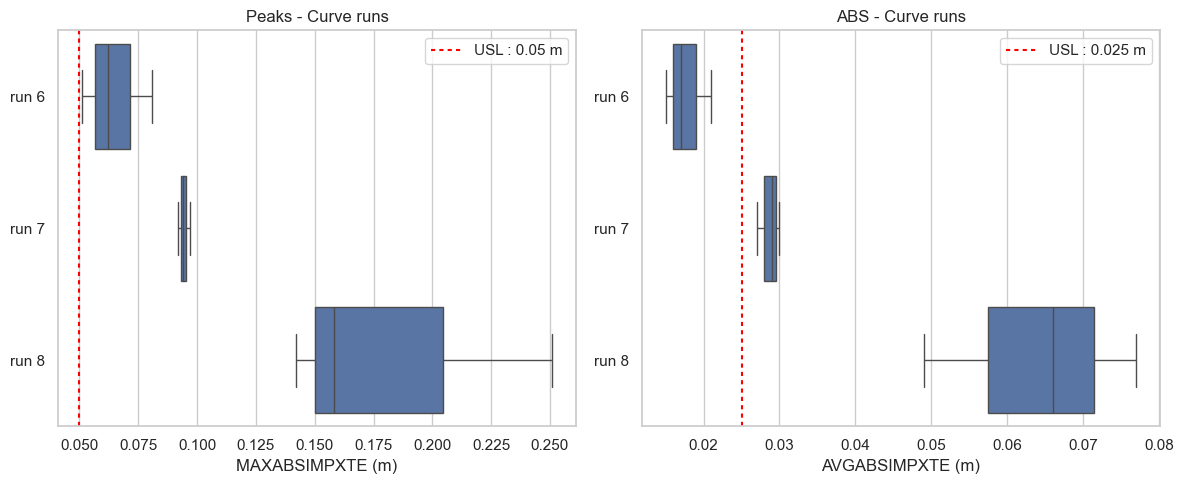

In [128]:
# Start by defining the figure. 
# row : 1, columns: 2

# Width: 12
# Height : 5
fig, axes = plt.subplots(1,2,figsize = (12,5))


# Definition of groups 

curve_groups = [
              'run 6', 'run 6', 'run 6',
              'run 7', 'run 7', 'run 7',
              'run 8', 'run 8', 'run 8',
              
              ]

# Plot the second boxplot. Peaks on Curve runs 

sns.boxplot(y = curve_groups, 
            x = df_curves["MAXABSIMPXTE (m)"],
            ax = axes[0])

###

axes[0].set_title("Peaks - Curve runs")
axes[0].axvline(spec_peaks,color = 'red', dashes = (2,2), label = 'USL : 0.05 m')

axes[0].legend()

sns.boxplot(y = curve_groups, 
            x = df_curves["AVGABSIMPXTE (m)"],
            ax = axes[1])

axes[1].set_title("ABS - Curve runs")
axes[1].axvline(spec_abs,color = 'red', dashes = (2,2), label = 'USL : 0.025 m')

axes[1].legend()

plt.tight_layout()
plt.savefig('Curve_Plots.png', dpi=300)
plt.close

In [129]:
#Se crea una minifuncion que toma como entrada el SUB-DATAFRAME de cada run (run_x_ranges).


#Entrega una tupla que contine dos valores.
#   1. El promedio de las columna MAXABSIMPXTE (m) 
#   2. El promedio de la columna  AVGABSIMPXTE (m)


def compute_mean(range_run):
    avg_peaks = range_run['MAXABSIMPXTE (m)'].mean()
    avg_abs = range_run['AVGABSIMPXTE (m)'].mean()
    return avg_peaks, avg_abs

In [130]:
#Se aplica la funcion en cada SUB-DATAFRAME por cada run 

#Online runs
avg_run_1 = compute_mean(run_1_ranges)
avg_run_2 = compute_mean(run_2_ranges)
avg_run_3 = compute_mean(run_3_ranges)
avg_run_4 = compute_mean(run_4_ranges)
avg_run_5 = compute_mean(run_5_ranges)

#Curve runs
avg_run_6 = compute_mean(run_6_ranges)
avg_run_7 = compute_mean(run_7_ranges)
avg_run_8 = compute_mean(run_8_ranges)


In [131]:
# Se asigna a cada renglon las tuplas que contien
# los promedios AXABSIMPXTE (m) y AVGABSIMPXTE (m) en el dataframe de salida (output_df_results)


output_df_results.loc[1] = avg_run_1
output_df_results.loc[2] = avg_run_2
output_df_results.loc[3] = avg_run_3
output_df_results.loc[4] = avg_run_4
output_df_results.loc[5] = avg_run_5
output_df_results.loc[6] = avg_run_6
output_df_results.loc[7] = avg_run_7
output_df_results.loc[8] = avg_run_8


In [132]:
#Crea una lista de 1 a 10. 
# Esta columna solo tendra el numero de las corridas . 
# Online - 5 corridas, Curves - 3 corridas

runs_index = [f"run {i}" for i in range(1, 10)]
runs_index = pd.Series(runs_index)
runs_index.index = range(1,10)


#Crea una lista en donde sea FAIL si el promedio encontrado en PEAK AVG (m) 
# para esa corrida es MAYOR al spec_PEAKS = .05 m
peak_results = ["Fail" if peak_run > spec_peaks else "Pass" for peak_run in output_df_results["PEAKS AVG (m)"]]
peak_results = pd.Series(peak_results)
peak_results.index = range(1,9)


#Crea una lista en donde sea FAIL si el promedio encontrado en ABS AVG (m) 
# para esa corrida es MAYOR al spec_ABS = .025 m
abs_results = ["Fail" if peak_run > spec_abs else "Pass" for peak_run in output_df_results["ABS AVG (m)"]]
abs_results = pd.Series(abs_results)
abs_results.index = range(1,9)


In [133]:
#Crea una columna llamada 'RUN' en el df output_df y se asigna la lista 
#creada en el paso anterior. La lista contine unicamente el nombre de las corridas
# runs = [run 1, run 2, ... run5 ]
output_df_results['Run'] = runs_index

#Crea una columna llamada 'STATUS - PEAKS AVG' en el df output_df 
# y se le asigna la lista (peak_results) que contiene los resultados obtenidos (Pass o Fail).
output_df_results['STATUS - PEAKS AVG'] = peak_results

#Crea una columna llamada 'STATUS ABS AVG' en el df output_df 
# y se le asigna la lista (abs_results) que contiene los resultados obtenidos (Pass o Fail).
output_df_results['STATUS ABS AVG'] = abs_results

#Reordena las columnas en este orden en el dataframe de salida
# 'RUN','PEAKS AVG (m)','STATUS - PEAKS AVG','ABS AVG (m)','STATUS ABS AVG'
output_df_results = output_df_results[['Run','PEAKS AVG (m)','STATUS - PEAKS AVG','ABS AVG (m)','STATUS ABS AVG']]


<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

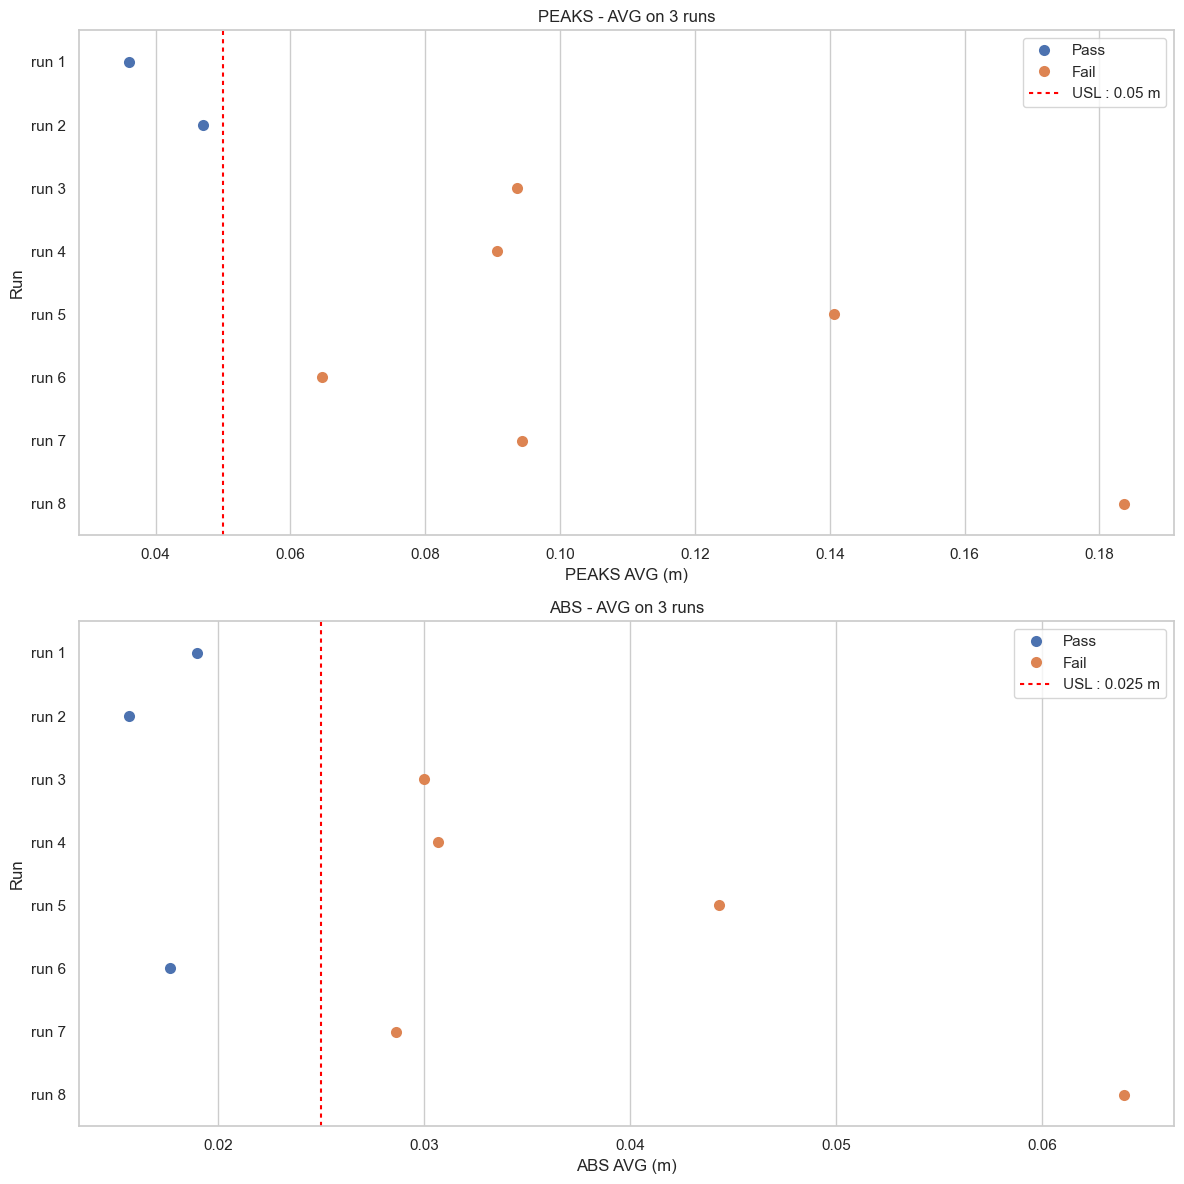

In [136]:
# Start by defining the figure. 
# row : 1, columns: 2

# Width: 12
# Height : 5
fig, (ax1,ax2) = plt.subplots(2,1,figsize = (12,12))



# Plot the first subplot. Average of peaks.

sns.set_theme(style="whitegrid")

sns.stripplot( 
    y=output_df_results['Run'],      # Your 5 experimental settings
    x=output_df_results['PEAKS AVG (m)'],               # Your measured metric
    hue=output_df_results['STATUS - PEAKS AVG'],        # Split colors by spec compliance
    size=8, 
    jitter=0.5,           # Spread points horizontally so they don't overlap
    ax=ax1
)


ax1.set_title("PEAKS - AVG on 3 runs")
ax1.axvline(spec_peaks,color = 'red', dashes = (2,2), label = 'USL : 0.05 m')
ax1.legend()

# Plot the second subplot. Average of peaks.

sns.stripplot( 
    y=output_df_results['Run'],      # Your 5 experimental settings
    x=output_df_results['ABS AVG (m)'],               # Your measured metric
    hue=output_df_results['STATUS ABS AVG'],        # Split colors by spec compliance
    size=8, 
    jitter=0.5,           # Spread points horizontally so they don't overlap
    ax=ax2
)


ax2.set_title("ABS - AVG on 3 runs")
ax2.axvline(spec_abs,color = 'red', dashes = (2,2), label = 'USL : 0.025 m')
ax2.legend()


plt.tight_layout()
plt.savefig('averages_results.png', dpi=300)
plt.close

In [137]:
# Se exportan los dataframes al mismo excel file. 
# Sheet name nos sirve para especificar el nombre que llevara la sheet donde se exportara el df

with pd.ExcelWriter(filename_excel_report) as writer:
    df_online.to_excel(writer, sheet_name= 'Online Runs',index=False)
    df_curves.to_excel(writer, sheet_name= 'Curve Runs',index=False)
    output_df_results.to_excel(writer,sheet_name= 'Summary Results',index=False)


In [138]:
#Se abre el archivo usando openpyxl

#Aqui solo se crea la instancia para manipular el excel usando la libreria openpyxl
wb_file = load_workbook(filename_excel_report) 

#Seleccionamos la hoja que contine los resultados 
wb_sheet = wb_file['Summary Results']

#Se crean los colores para cada celda
green_code = "C6EFCE"
red_code = "FFC7CE"


# start color: Excel pinta la celda usando cierto patron, ya sea puntos o lineas,
# start color es en palabras resumidas el color de esos puntos con los que se llena la celda

green_fill = PatternFill(start_color = green_code,
                         fill_type= 'solid')


red_fill = PatternFill(start_color = red_code,
                       fill_type = 'solid' )

 # Aqui se tomaran las columnas C (3) y la E (5) que tiene los resultados de Pass/Fail

status_columns = [3,5]


# Comenzamos desde el row 2, ya que no necesitamos leer el heading the la columna 
# contamos los siguientes 8 rows que contien los Pass o Fail por columna 
# cuando row es igual a 10, sale del bucle
for row in range(2,10):

    for col in status_columns:
        
        cell = wb_sheet.cell(row = row, column = col)

        if cell.value == "Pass":
            cell.fill = green_fill

        else:
            cell.fill = red_fill

wb_file.save(filename_excel_report)


In [139]:
#Seleccionamos la hoja que contine las corridas Online 
wb_sheet_Online_Runs = wb_file['Online Runs']

#Seleccionamos la hoja que contiene las corridas Curve
wb_sheet_Curve_Runs = wb_file['Curve Runs']

#Seleccionamos la hoja que contiene las corridas con todos los resultaos
wb_sheet_Summary_Results = wb_file['Summary Results']


online_plots = Image('Online_Plots.png')
curve_plots = Image('Curve_Plots.png')
avgs_plots = Image('averages_results.png')


wb_sheet_Online_Runs.add_image(online_plots, 'I2')
wb_sheet_Curve_Runs.add_image(curve_plots, 'I2')
wb_sheet_Summary_Results.add_image(avgs_plots, 'I2')



wb_file.save(filename_excel_report)